# Import and Install Library

In [1]:
#download and install langchain dependencies
!pip install -qU qdrant-client langchain-openai langchain-qdrant

In [2]:
# importing all libraries needed
import pandas as pd #for data processing
import getpass, os #for input password interface

from langchain_openai import OpenAIEmbeddings, ChatOpenAI #for embedding and LLM service
from uuid import uuid4 #for generate id with uuid format

from langchain_core.documents import Document #for document format that stored to vector database collection
from langchain_qdrant import QdrantVectorStore #for langchain - qdrant vector database connector
from qdrant_client import QdrantClient #for qdrant client set up
from qdrant_client.http.models import Distance, VectorParams #for distance method and configuration of vector parameters

# Setup Environment API_KEY

In [3]:
from google.colab import userdata

# input openai api key
if userdata.get('OPENAI_API_KEY'):
  os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
else:
  os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

In [15]:
# input qdrant api key and url
if userdata.get('QDRANT_API_KEY'):
  api_key_qdrant = userdata.get('QDRANT_API_KEY')
else:
  api_key_qdrant = getpass.getpass("Enter API key for Qdrant: ")
print("QDRANT API KEY telah diinput")

if userdata.get('QDRANT_URL'):
  url_qdrant = userdata.get('QDRANT_URL')
else:
  url_qdrant = getpass.getpass("Enter URL for Qdrant: ")
print("QDRANT URL telah diinput")

QDRANT API KEY telah diinput
QDRANT URL telah diinput


# Define LLM and Processing Dataset

In [5]:
#define embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

#define llm model
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

In [6]:
#define directory path of dataset
data_path = "/content/drive/MyDrive/JCAIEAH-003/Notes and Hands On/Modul 3/Day 10/flipkart_com-ecommerce_sample.csv"

In [7]:
#read dataset with pandas
df = pd.read_csv(data_path)
print(df.shape) #show total row and column with format (row, column)
df.head() #show first 5 record of dataset

(20000, 15)


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


In [8]:
data = df.copy() #copy data table
data = data.iloc[:1000,].reset_index(drop=True)
data = data.dropna(subset=['description', 'product_name']).reset_index(drop=True) #delete rows that contain missing values
data = data.drop_duplicates(subset=['description', 'product_name']).reset_index(drop=True) #delete duplicate rows
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


In [9]:
#delete rows that contain missing value in specific columns: 'description' and 'product_name'
data = data.dropna(subset=['description', 'product_name'])

In [10]:
#looping and set the data into Document format
documents = []
for i in range(data.shape[0]):
  product_name = data["product_name"][i]
  product_desc = data["description"][i]
  product_id = data["uniq_id"][i]
  doc = Document(
      page_content=f"{product_name}\n{product_desc}",
      metadata={"product_id": str(product_id), "title": str(product_name),},
  )
  documents.append(doc)

#setup unique id
uuids = [str(uuid4()) for _ in range(len(documents))]

In [11]:
#show a sample document
documents[0]

Document(metadata={'product_id': 'c2d766ca982eca8304150849735ffef9', 'title': "Alisha Solid Women's Cycling Shorts"}, page_content="Alisha Solid Women's Cycling Shorts\nKey Features of Alisha Solid Women's Cycling Shorts Cotton Lycra Navy, Red, Navy,Specifications of Alisha Solid Women's Cycling Shorts Shorts Details Number of Contents in Sales Package Pack of 3 Fabric Cotton Lycra Type Cycling Shorts General Details Pattern Solid Ideal For Women's Fabric Care Gentle Machine Wash in Lukewarm Water, Do Not Bleach Additional Details Style Code ALTHT_3P_21 In the Box 3 shorts")

# Vector Database Process

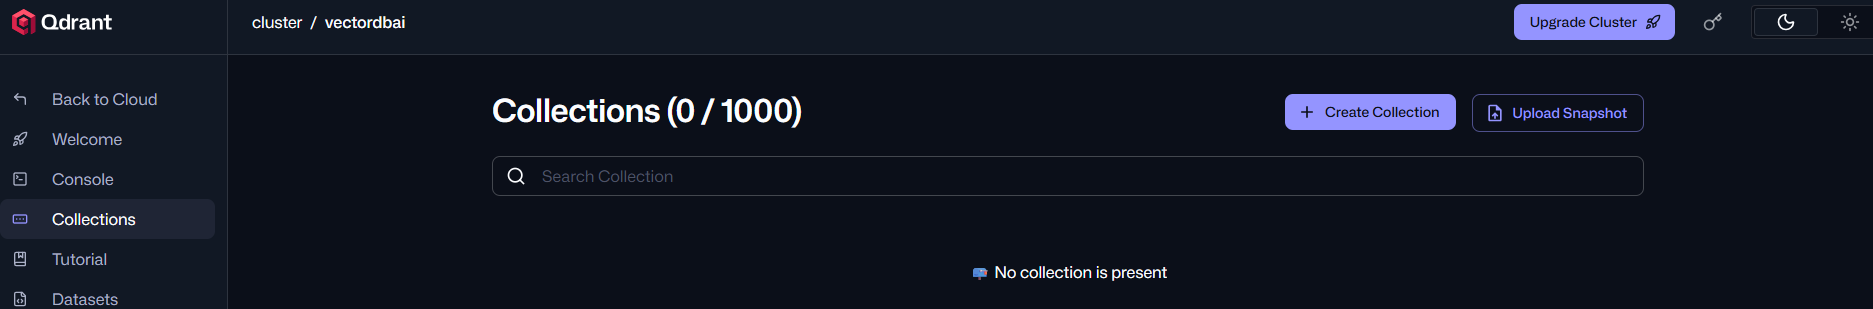

In [ ]:
#save document to qdrant
qdrant = QdrantVectorStore.from_documents(
    documents,
    embeddings,
    url=url_qdrant,
    prefer_grpc=True,
    api_key=api_key_qdrant,
    collection_name="product_documents",
)

In [ ]:
# # for deleting collection

# client = QdrantClient(
#   url= url_qdrant,
#   api_key = api_key_qdrant
# )
# client.delete_collection(collection_name="product_documents")

In [ ]:
#setup qdrant client
client = QdrantClient(
  url= url_qdrant,
  api_key = api_key_qdrant
)
#get all collection in your qdrant vector database
collections_response = client.get_collections()
print("Collections:", collections_response.collections)

Collections: [CollectionDescription(name='product_documents')]


# Query in VectorDB

In [17]:
#qdrant vectorstore with specific collection name
qdrant = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name="product_documents",
    url=url_qdrant,
    api_key=api_key_qdrant
)

In [18]:
#retrieve data from qdrant
results = qdrant.similarity_search(
    "Women's Cycling Shorts",
    k=2
)
results

[Document(metadata={'title': "Alisha Solid Women's Cycling Shorts", 'product_id': '4044c0ac52c1ee4b28777417651faf42', '_id': '94477687-122a-4d96-ad10-9c044e0bc6f9', '_collection_name': 'product_documents'}, page_content="Alisha Solid Women's Cycling Shorts\nKey Features of Alisha Solid Women's Cycling Shorts Cotton Lycra White, Black, Red, Black,Specifications of Alisha Solid Women's Cycling Shorts Shorts Details Number of Contents in Sales Package Pack of 4 Fabric Cotton Lycra Type Cycling Shorts General Details Pattern Solid Ideal For Women's Fabric Care Gentle Machine Wash in Lukewarm Water, Do Not Bleach Additional Details Style Code ALTGHT4P_39 In the Box 4 shorts"),
 Document(metadata={'title': "Alisha Solid Women's Cycling Shorts", 'product_id': 'ce5a6818f7707e2cb61fdcdbba61f5ad', '_id': '4e496841-c910-4df0-885c-6b87e9578696', '_collection_name': 'product_documents'}, page_content="Alisha Solid Women's Cycling Shorts\nKey Features of Alisha Solid Women's Cycling Shorts Cotton Ly

In [19]:
#parsing page content and metadata from retrieved data
for res in results:
    print(f"Result Page Content:  {res.page_content}\nResult Metadata: [{res.metadata}]")
    print("-----"*20)

Result Page Content:  Alisha Solid Women's Cycling Shorts
Key Features of Alisha Solid Women's Cycling Shorts Cotton Lycra White, Black, Red, Black,Specifications of Alisha Solid Women's Cycling Shorts Shorts Details Number of Contents in Sales Package Pack of 4 Fabric Cotton Lycra Type Cycling Shorts General Details Pattern Solid Ideal For Women's Fabric Care Gentle Machine Wash in Lukewarm Water, Do Not Bleach Additional Details Style Code ALTGHT4P_39 In the Box 4 shorts
Result Metadata: [{'title': "Alisha Solid Women's Cycling Shorts", 'product_id': '4044c0ac52c1ee4b28777417651faf42', '_id': '94477687-122a-4d96-ad10-9c044e0bc6f9', '_collection_name': 'product_documents'}]
----------------------------------------------------------------------------------------------------
Result Page Content:  Alisha Solid Women's Cycling Shorts
Key Features of Alisha Solid Women's Cycling Shorts Cotton Lycra Navy, Red, White, Red,Specifications of Alisha Solid Women's Cycling Shorts Shorts Details N

In [20]:
#try to retrieve data from vector database with similarity_search_with_score
#this method will give you additional information about similarity score
results = qdrant.similarity_search_with_score(
    "Women's Cycling Shorts",
    k=2
)
results

[(Document(metadata={'title': "Alisha Solid Women's Cycling Shorts", 'product_id': '4044c0ac52c1ee4b28777417651faf42', '_id': '94477687-122a-4d96-ad10-9c044e0bc6f9', '_collection_name': 'product_documents'}, page_content="Alisha Solid Women's Cycling Shorts\nKey Features of Alisha Solid Women's Cycling Shorts Cotton Lycra White, Black, Red, Black,Specifications of Alisha Solid Women's Cycling Shorts Shorts Details Number of Contents in Sales Package Pack of 4 Fabric Cotton Lycra Type Cycling Shorts General Details Pattern Solid Ideal For Women's Fabric Care Gentle Machine Wash in Lukewarm Water, Do Not Bleach Additional Details Style Code ALTGHT4P_39 In the Box 4 shorts"),
  0.65781903),
 (Document(metadata={'title': "Alisha Solid Women's Cycling Shorts", 'product_id': 'ce5a6818f7707e2cb61fdcdbba61f5ad', '_id': '4e496841-c910-4df0-885c-6b87e9578696', '_collection_name': 'product_documents'}, page_content="Alisha Solid Women's Cycling Shorts\nKey Features of Alisha Solid Women's Cycling

In [21]:
#parsing page content, metadata, and similarity score for each retrieved document
for res,score in results:
    print(f"Score: {score}\nResult Page Content:  {res.page_content}\nResult Metadata: [{res.metadata}]")
    print("-----"*20)

Score: 0.65781903
Result Page Content:  Alisha Solid Women's Cycling Shorts
Key Features of Alisha Solid Women's Cycling Shorts Cotton Lycra White, Black, Red, Black,Specifications of Alisha Solid Women's Cycling Shorts Shorts Details Number of Contents in Sales Package Pack of 4 Fabric Cotton Lycra Type Cycling Shorts General Details Pattern Solid Ideal For Women's Fabric Care Gentle Machine Wash in Lukewarm Water, Do Not Bleach Additional Details Style Code ALTGHT4P_39 In the Box 4 shorts
Result Metadata: [{'title': "Alisha Solid Women's Cycling Shorts", 'product_id': '4044c0ac52c1ee4b28777417651faf42', '_id': '94477687-122a-4d96-ad10-9c044e0bc6f9', '_collection_name': 'product_documents'}]
----------------------------------------------------------------------------------------------------
Score: 0.65505767
Result Page Content:  Alisha Solid Women's Cycling Shorts
Key Features of Alisha Solid Women's Cycling Shorts Cotton Lycra Navy, Red, White, Red,Specifications of Alisha Solid Wom

In [22]:
#retrieve data with non-default search_type.
#basically, default search_type is similarity_score_threshold, the code below shows how to retrieve with another search_type
retriever = qdrant.as_retriever(search_type="mmr", search_kwargs={"k": 1})
retriever.invoke("Women's Cycling Shorts")

[Document(metadata={'title': "Alisha Solid Women's Cycling Shorts", 'product_id': '4044c0ac52c1ee4b28777417651faf42', '_id': '94477687-122a-4d96-ad10-9c044e0bc6f9', '_collection_name': 'product_documents'}, page_content="Alisha Solid Women's Cycling Shorts\nKey Features of Alisha Solid Women's Cycling Shorts Cotton Lycra White, Black, Red, Black,Specifications of Alisha Solid Women's Cycling Shorts Shorts Details Number of Contents in Sales Package Pack of 4 Fabric Cotton Lycra Type Cycling Shorts General Details Pattern Solid Ideal For Women's Fabric Care Gentle Machine Wash in Lukewarm Water, Do Not Bleach Additional Details Style Code ALTGHT4P_39 In the Box 4 shorts")]